In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

eps = 0.1
size = 10

path_adv = f'../../output/matrices/matrices_{size}x{size}_eps_{eps}/payoff_matrices_adv.npy'
path_clean = f'../../output/matrices/matrices_{size}x{size}_eps_{eps}/payoff_matrices_clean.npy'

matriu_adv = np.load(path_adv)
matriu_clean = np.load(path_clean)

Detected 20 epochs. Generating visualizations...

VISUALIZING EPOCH 1/20


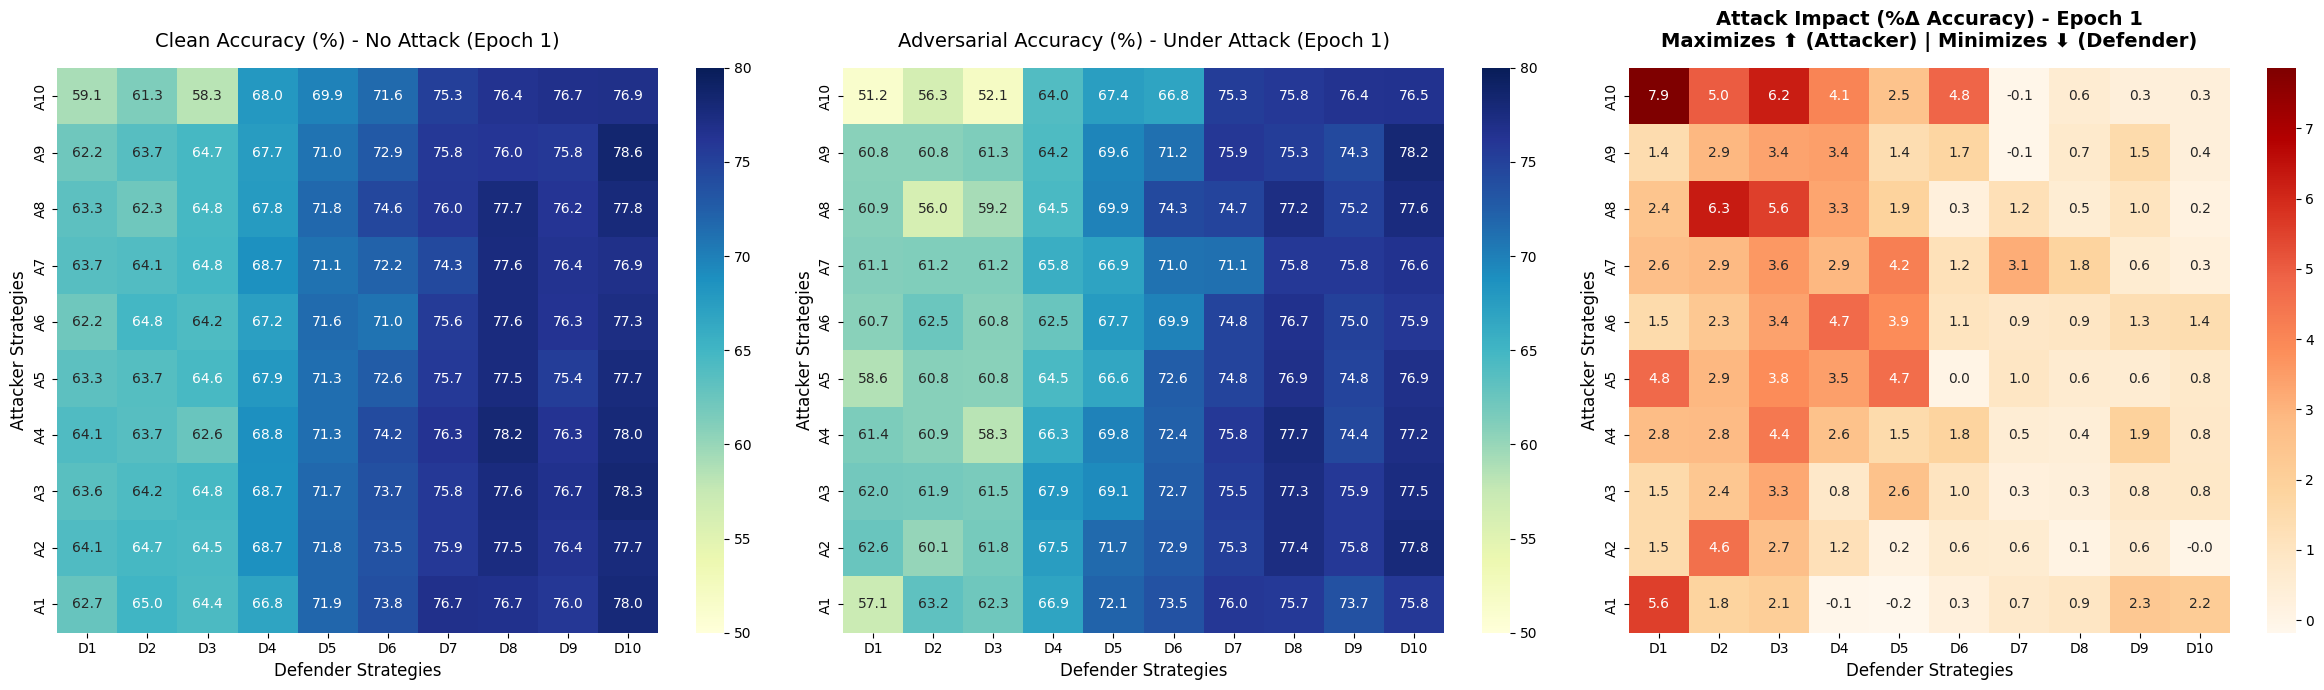



VISUALIZING EPOCH 2/20


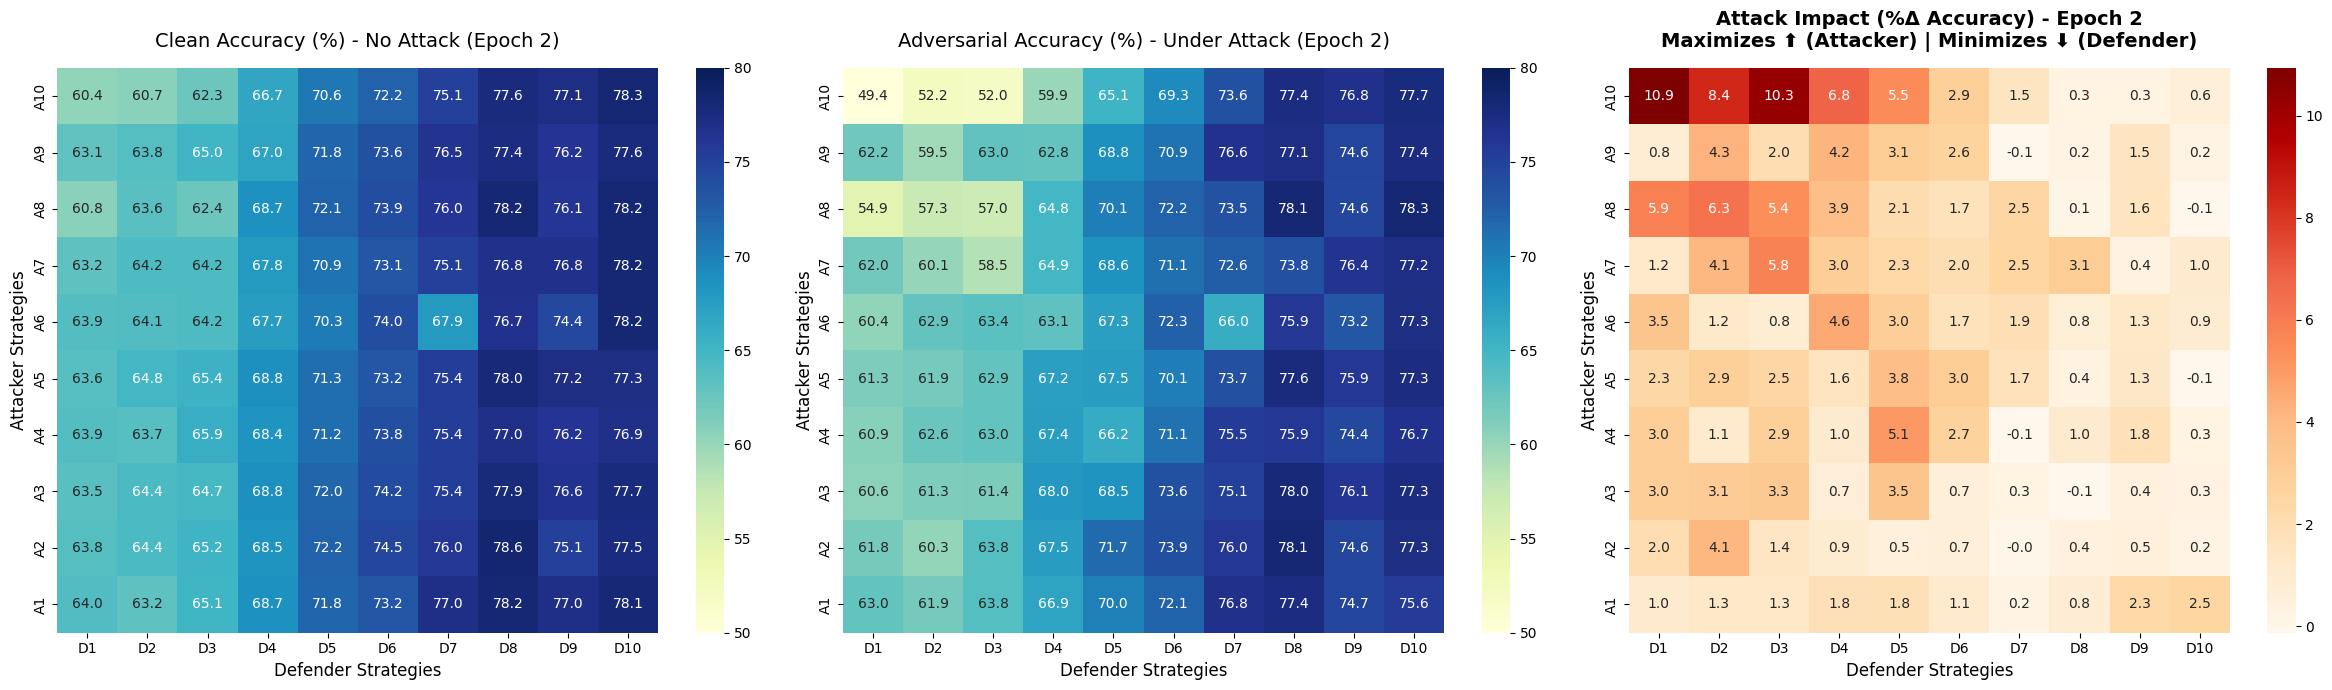



VISUALIZING EPOCH 3/20


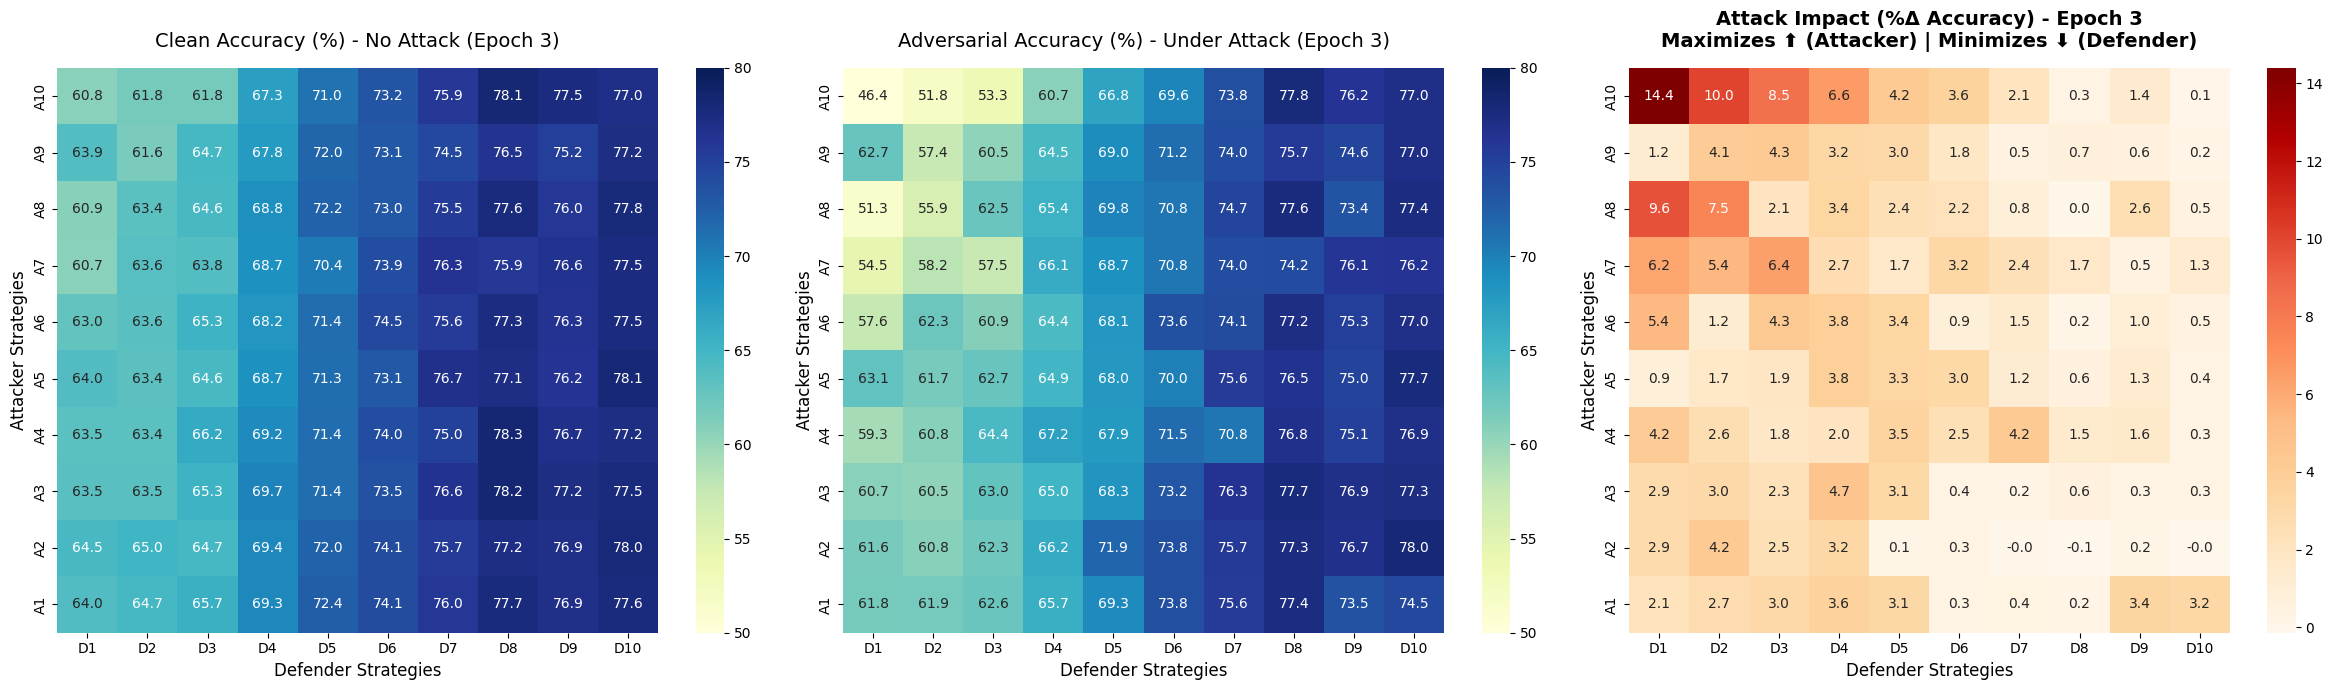



VISUALIZING EPOCH 4/20


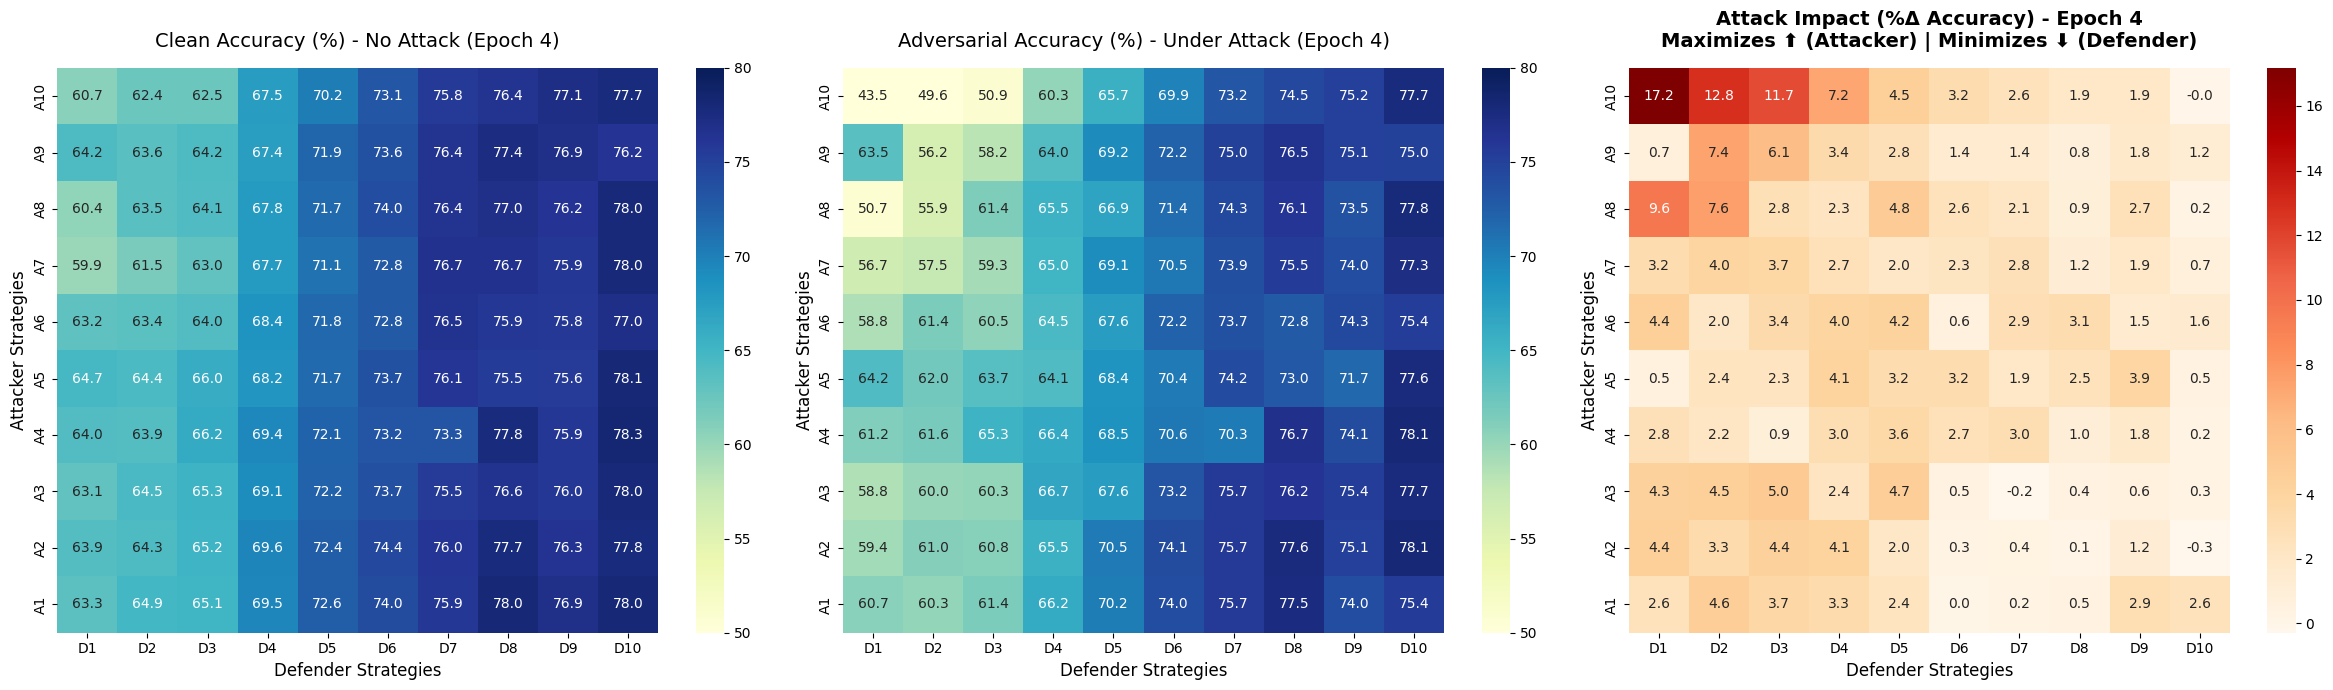



VISUALIZING EPOCH 5/20


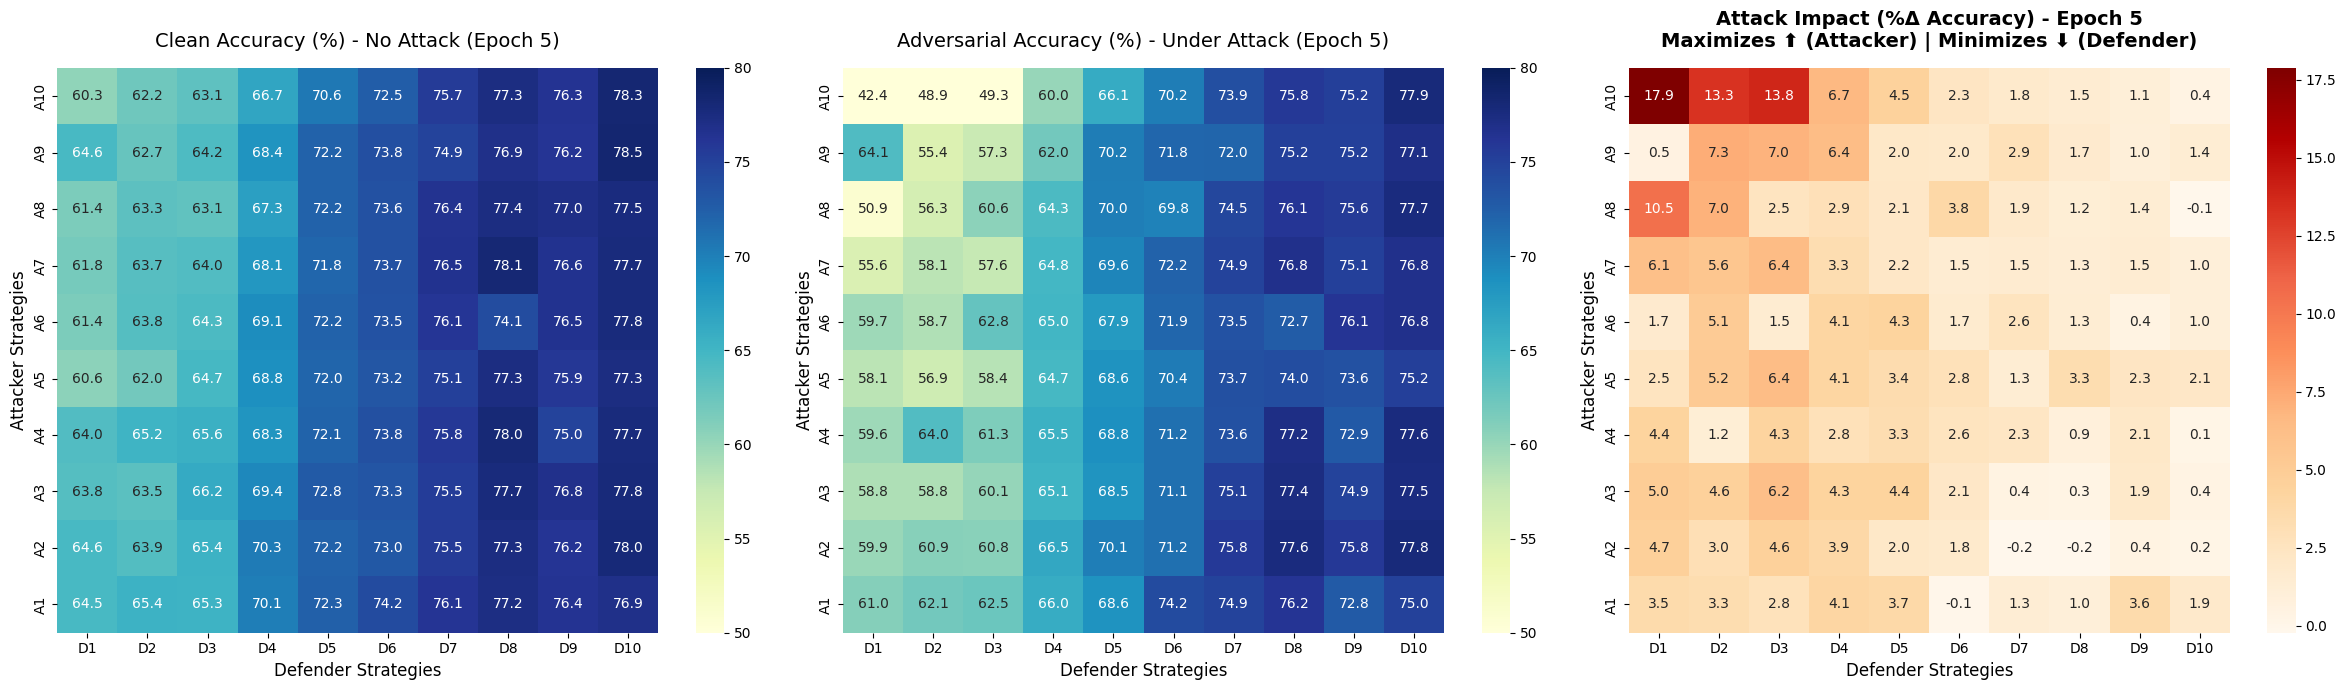



VISUALIZING EPOCH 6/20


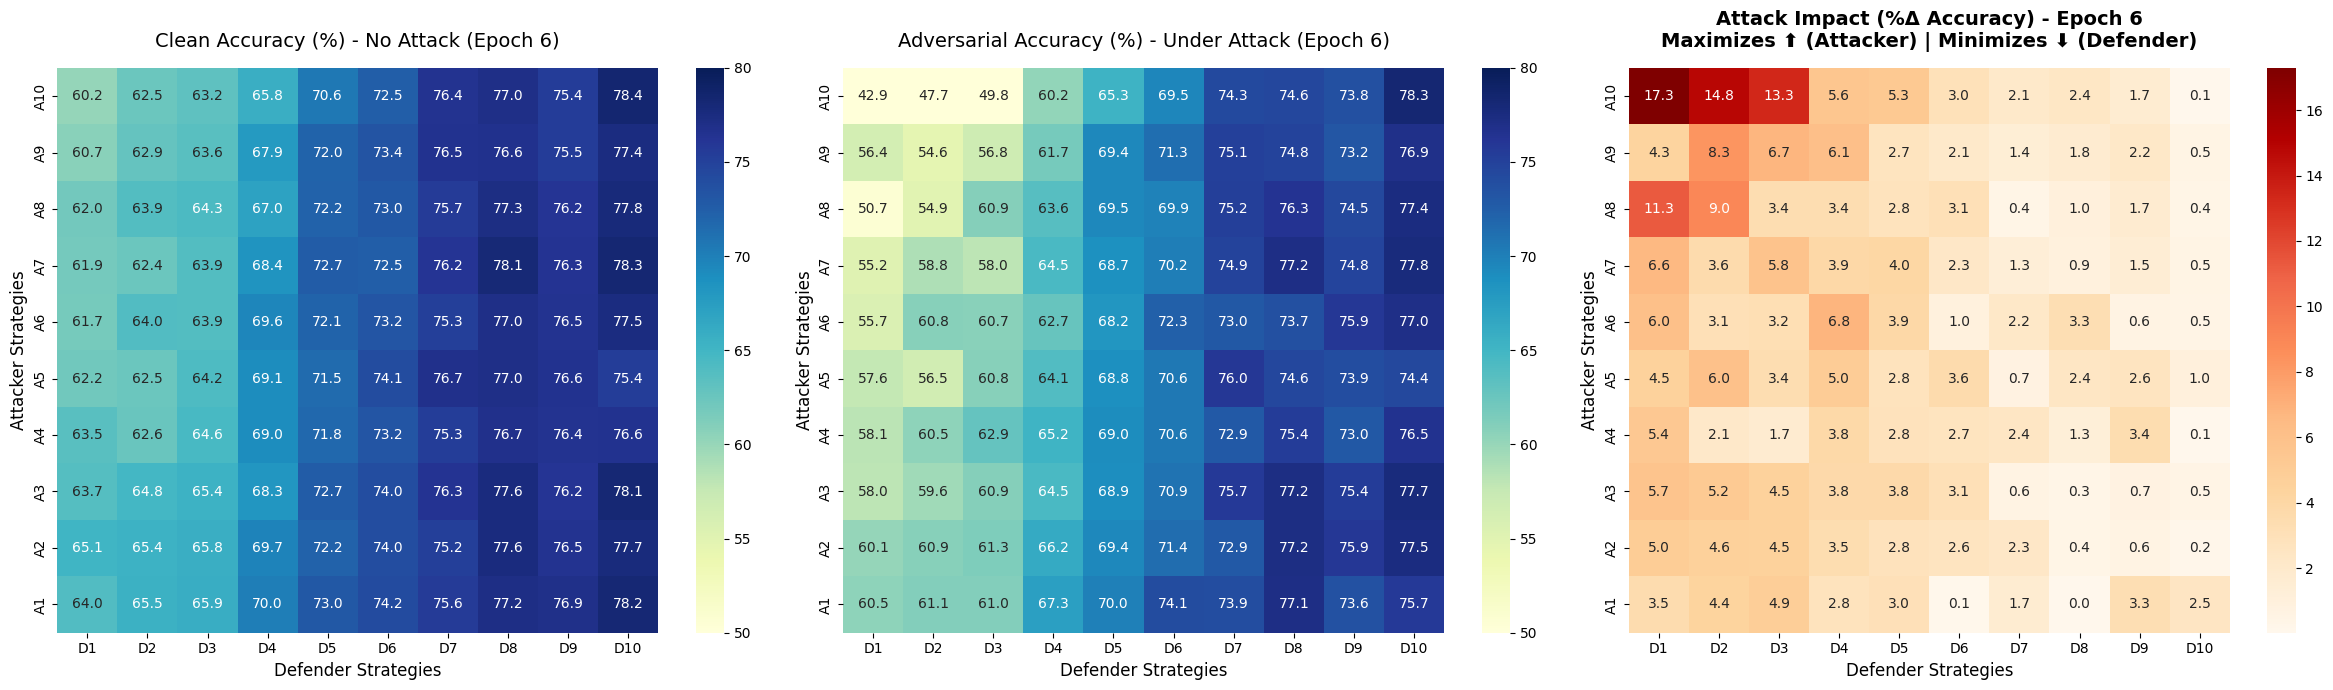



VISUALIZING EPOCH 7/20


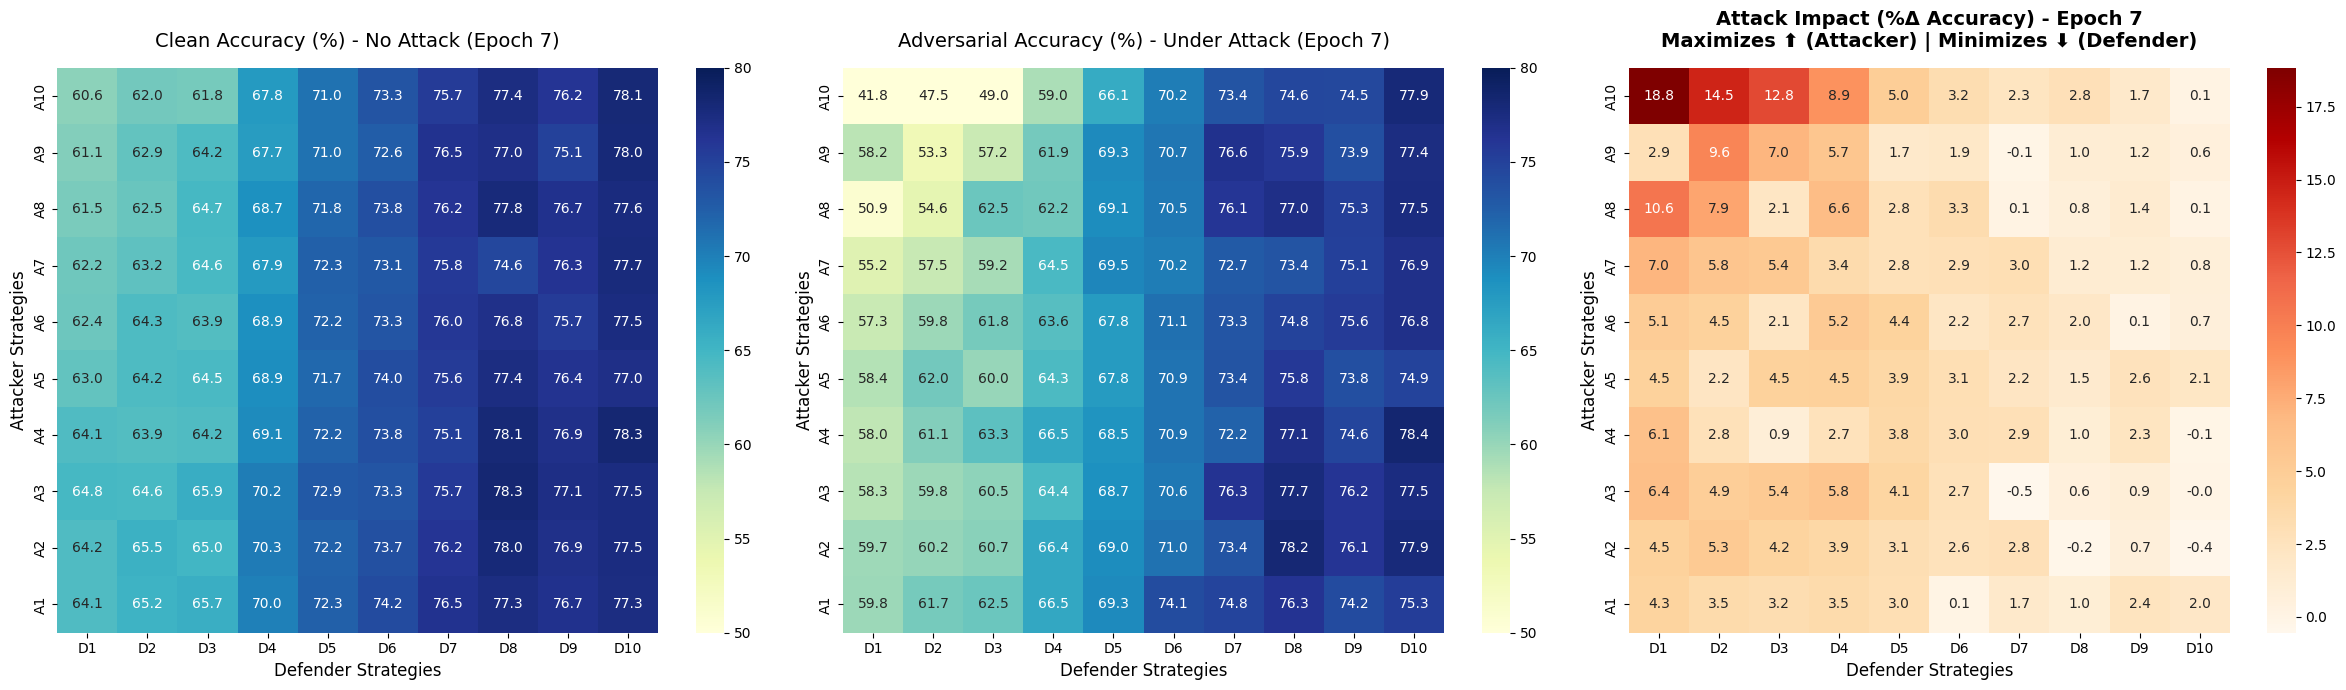



VISUALIZING EPOCH 8/20


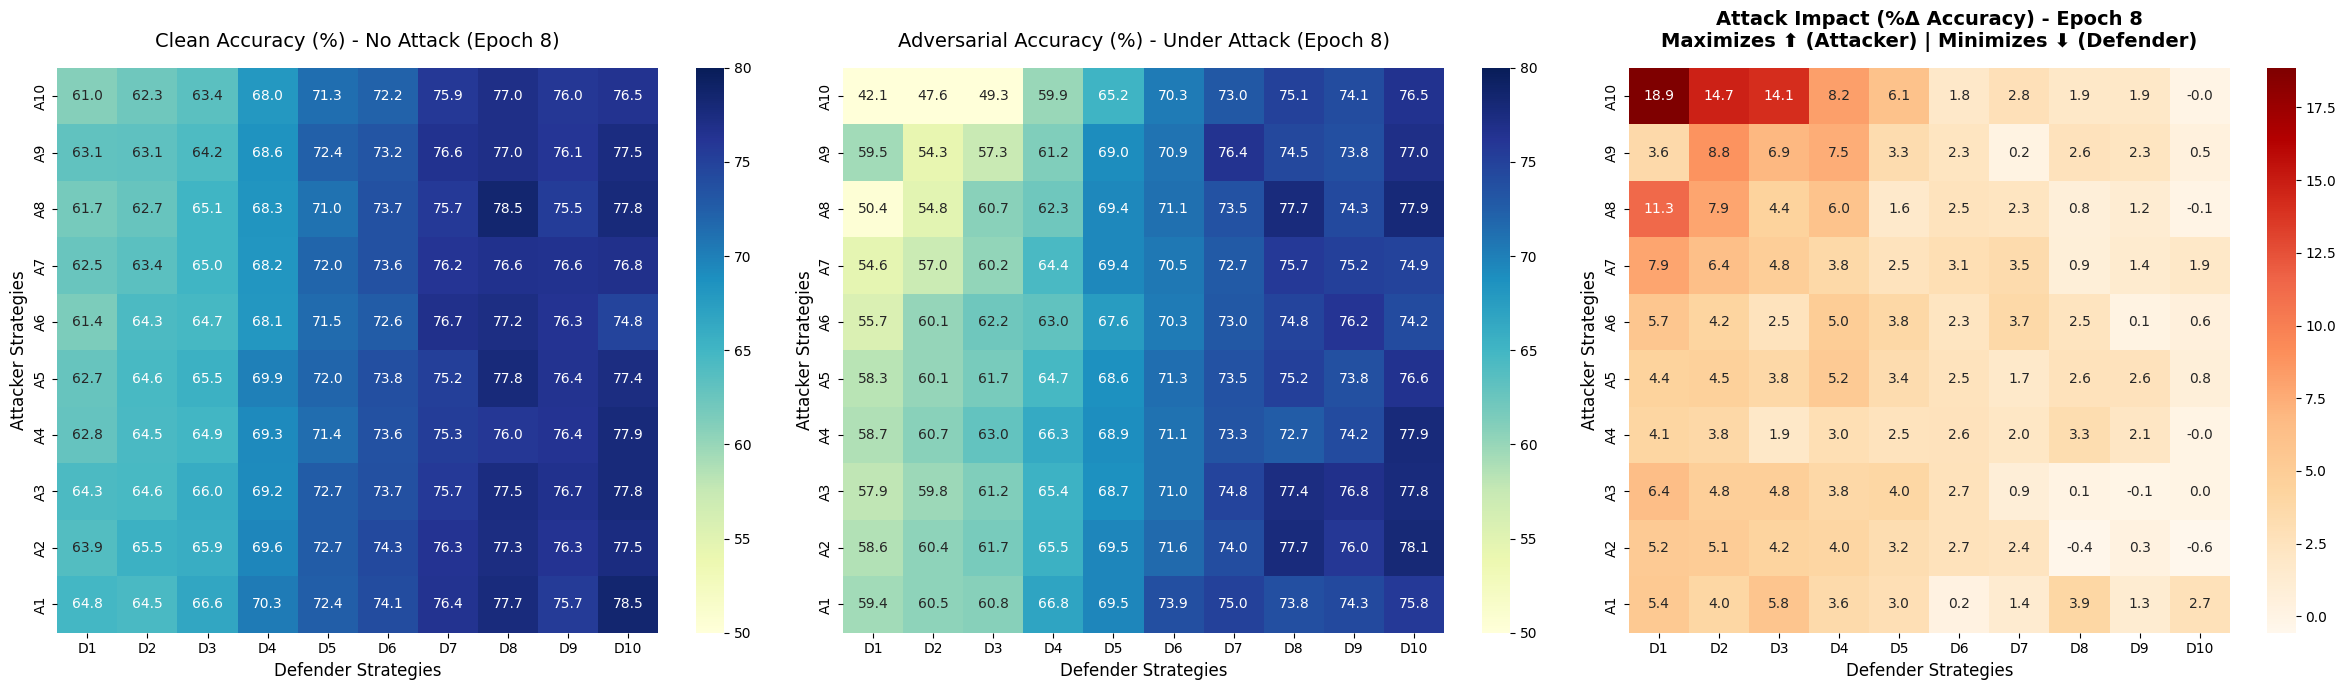



VISUALIZING EPOCH 9/20


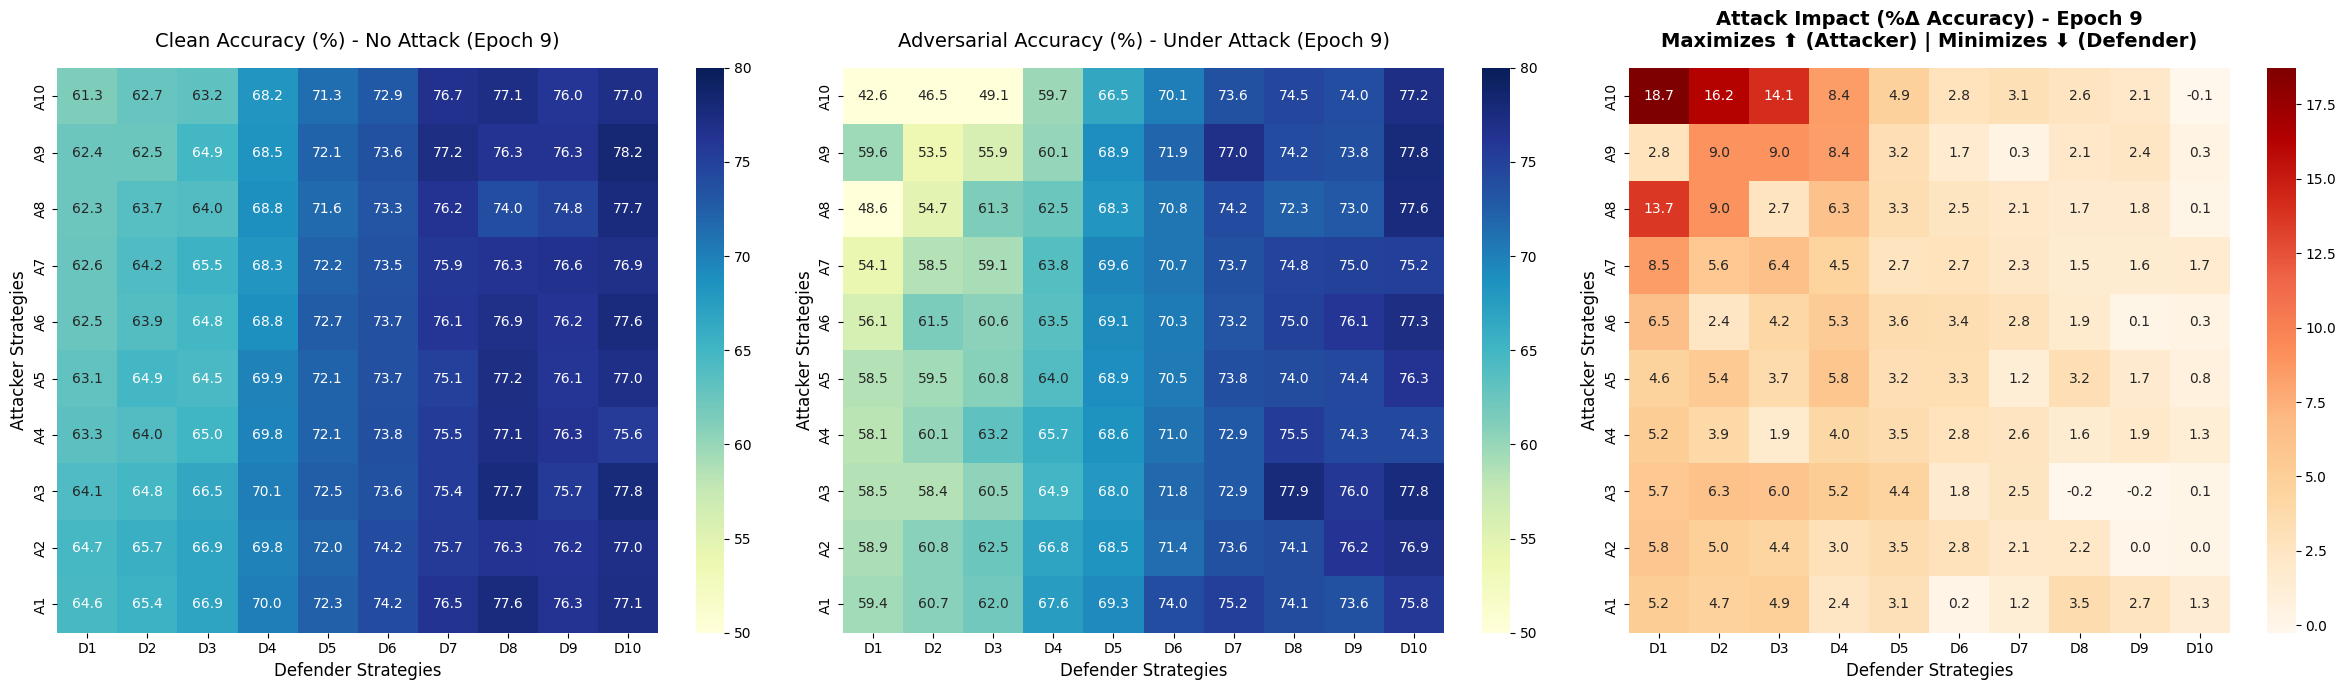



VISUALIZING EPOCH 10/20


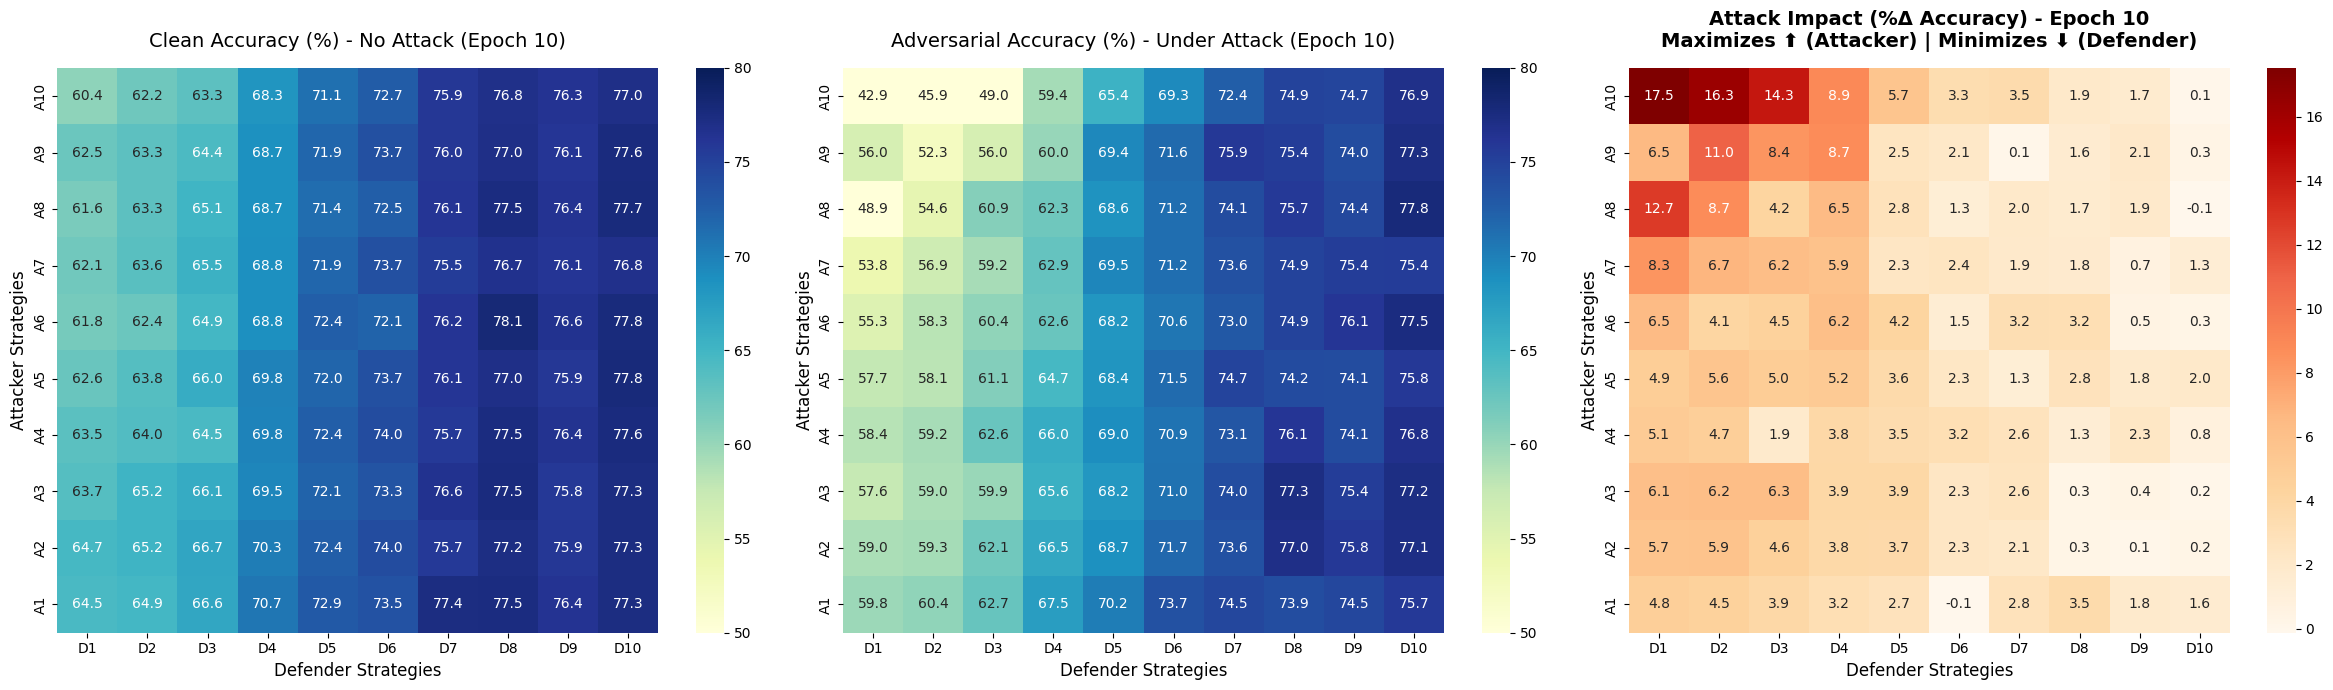



VISUALIZING EPOCH 11/20


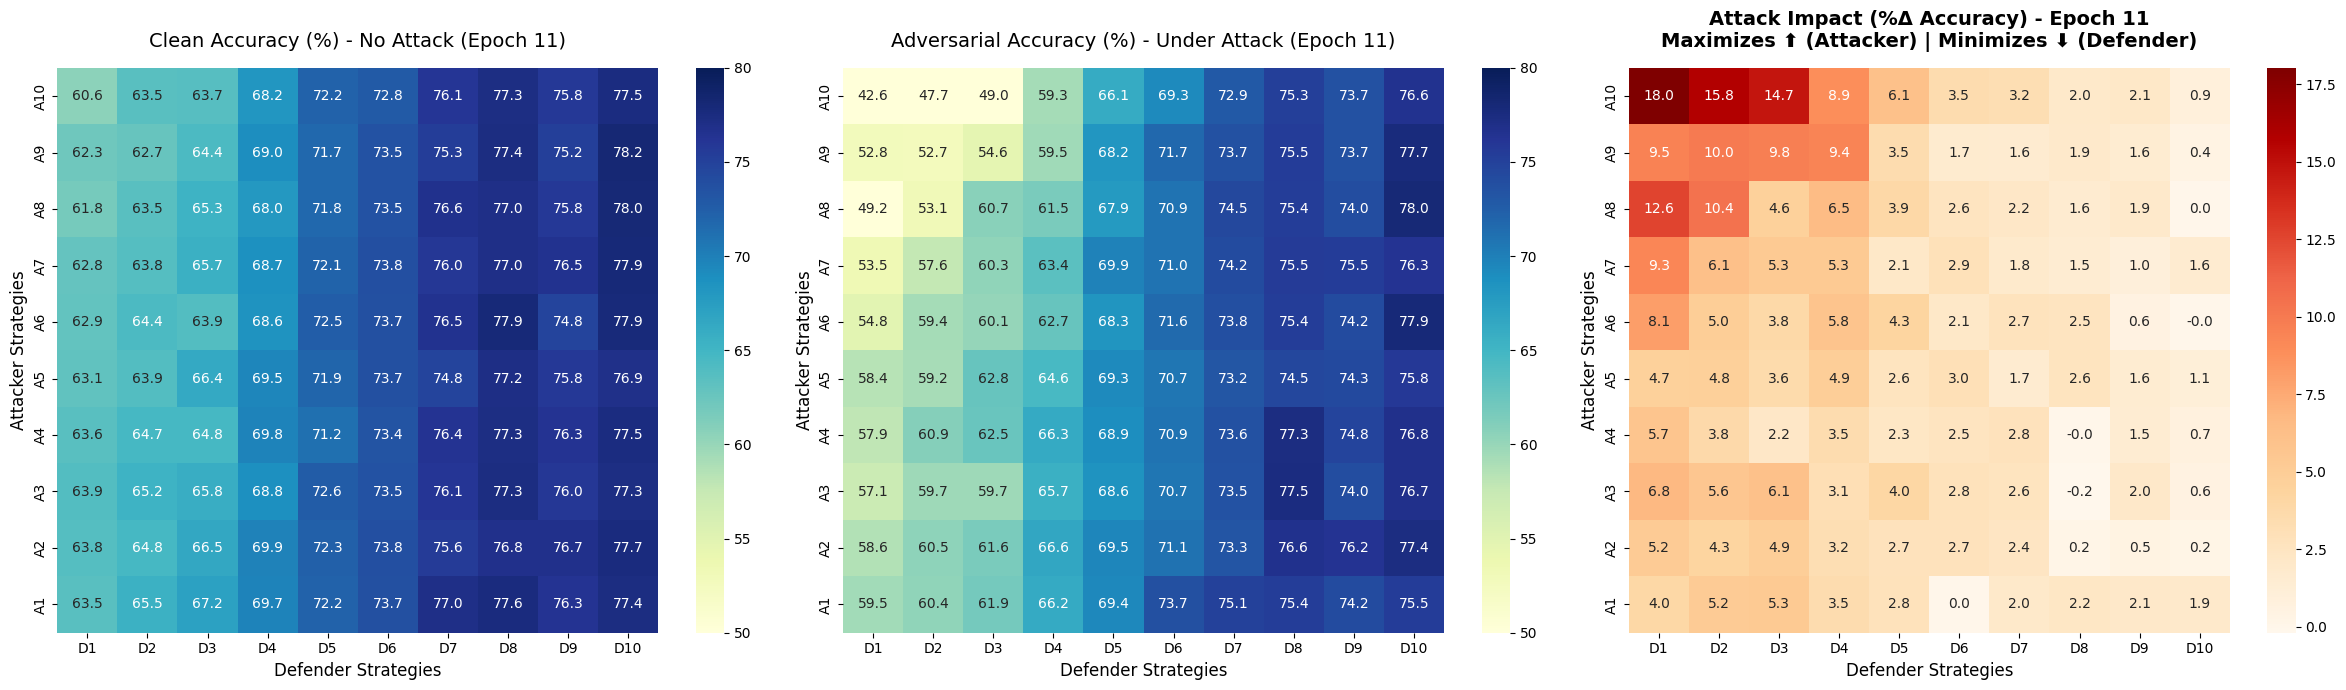



VISUALIZING EPOCH 12/20


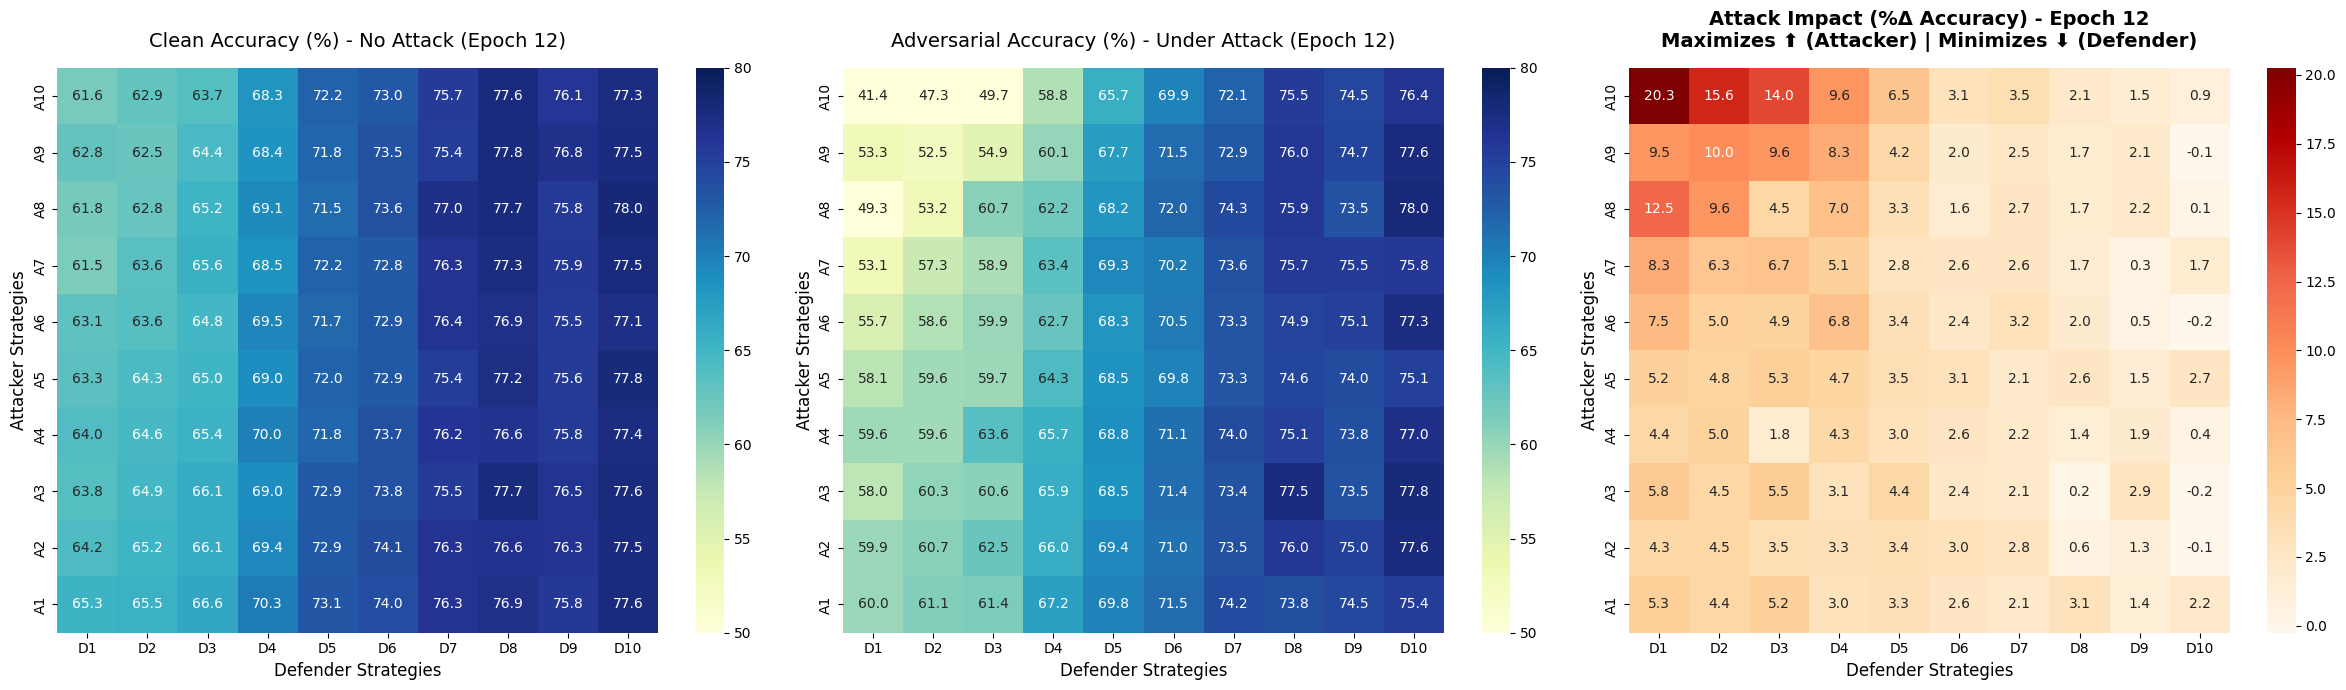



VISUALIZING EPOCH 13/20


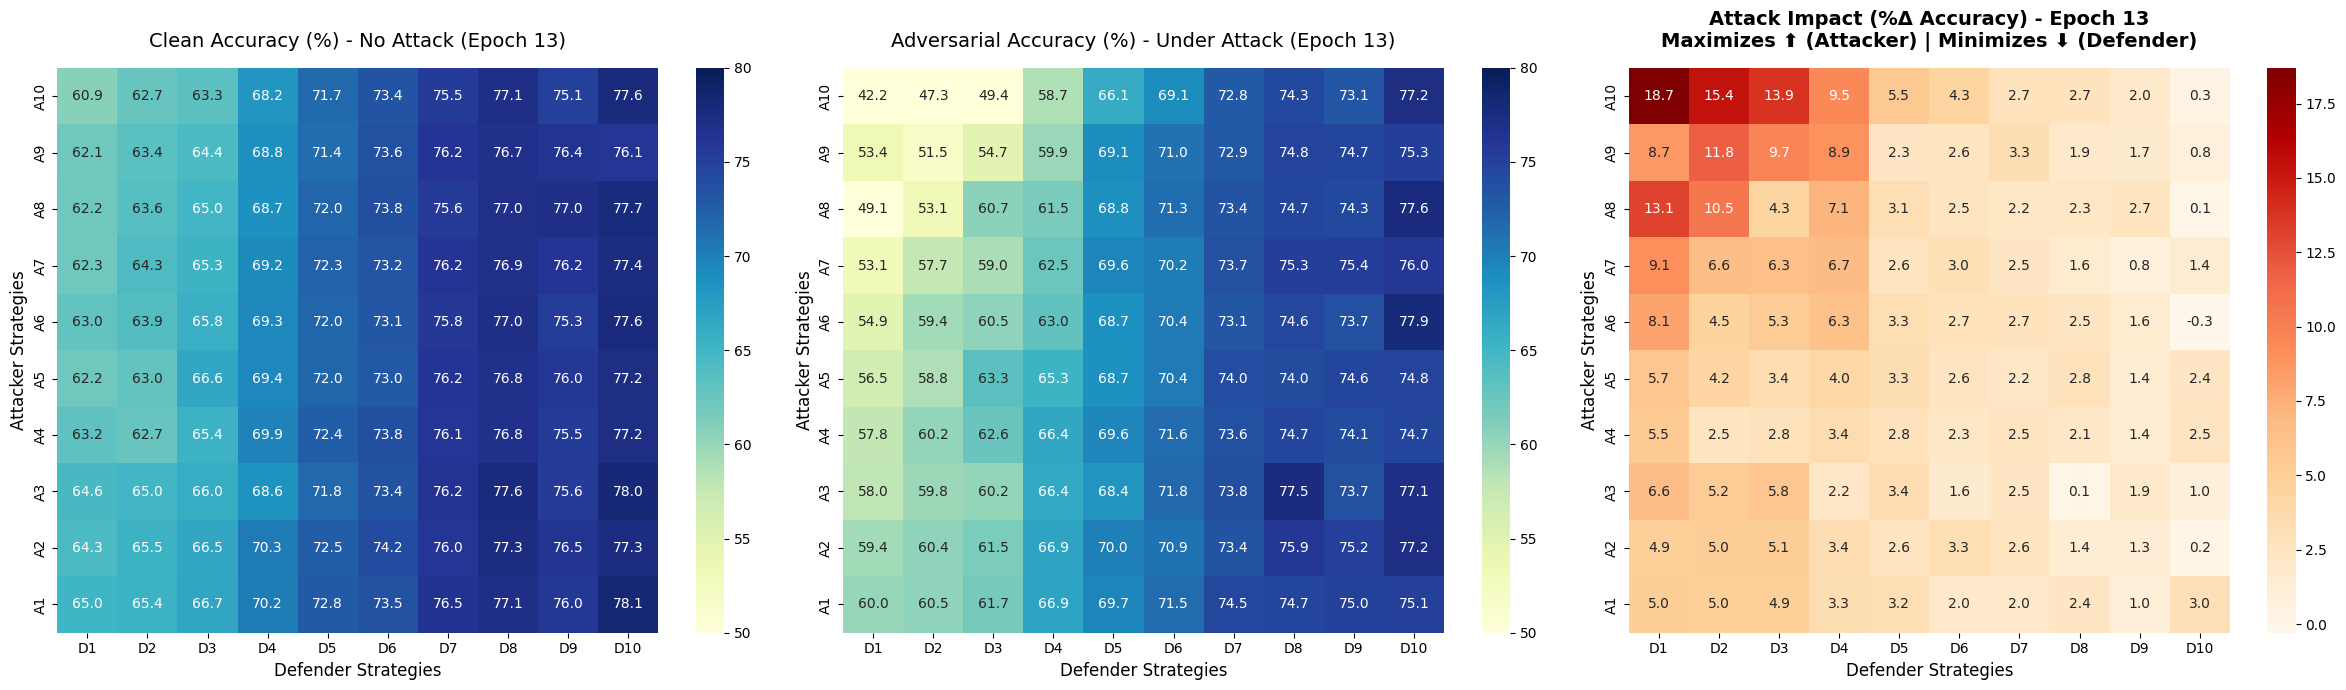



VISUALIZING EPOCH 14/20


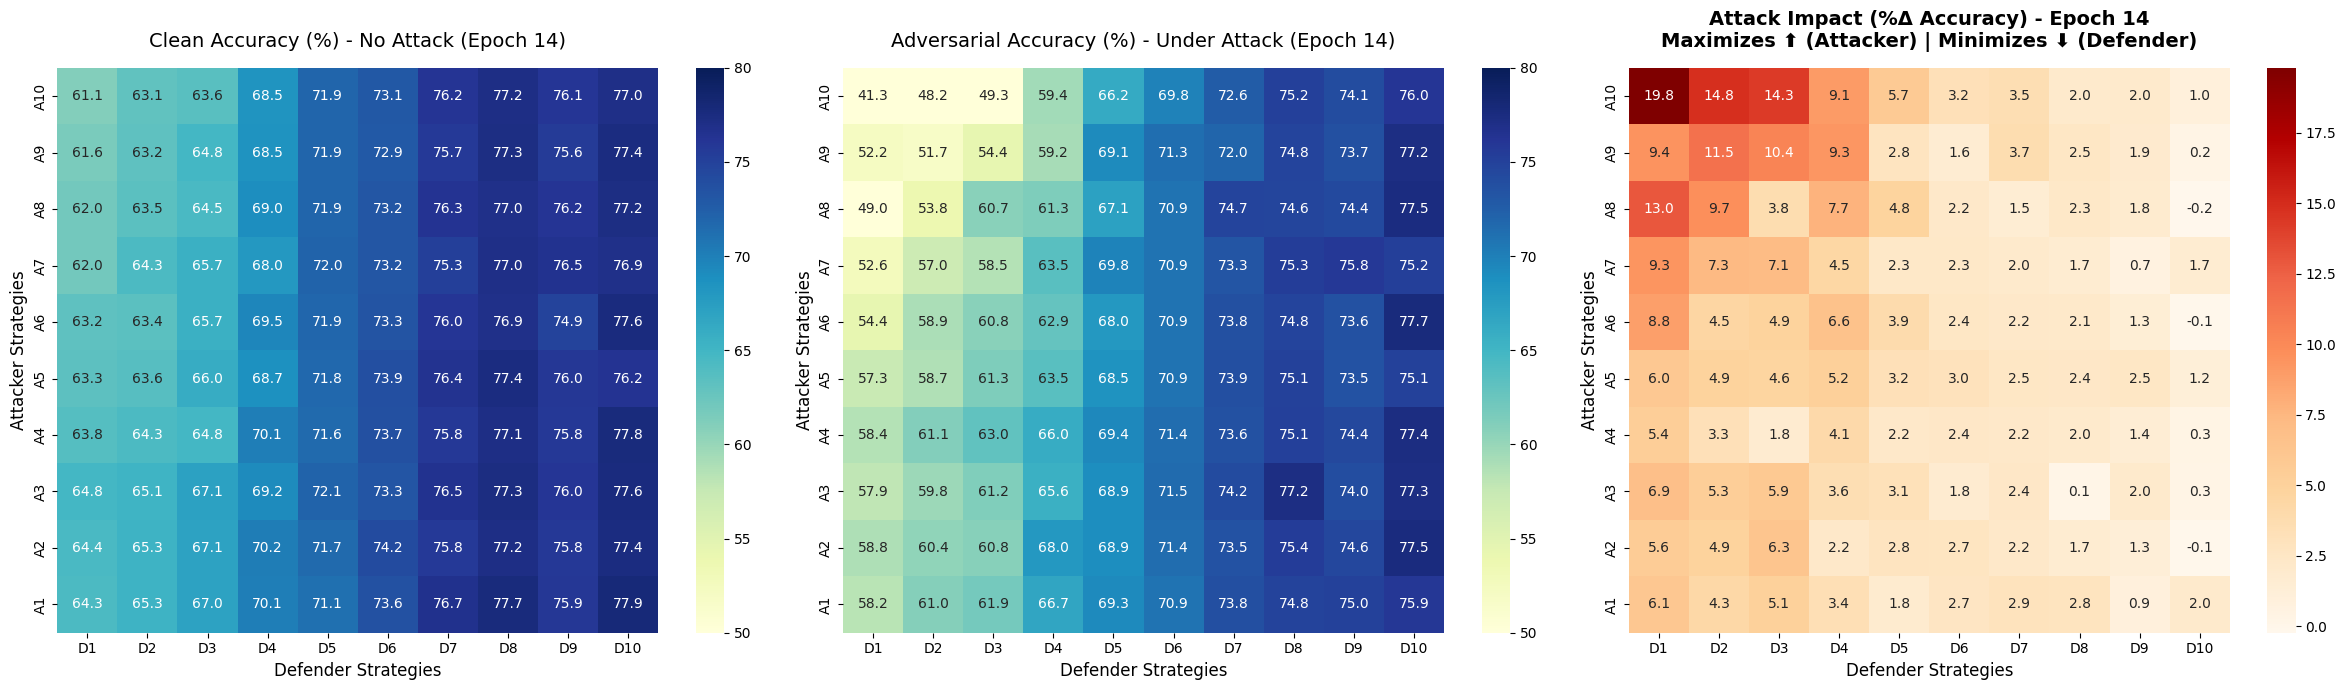



VISUALIZING EPOCH 15/20


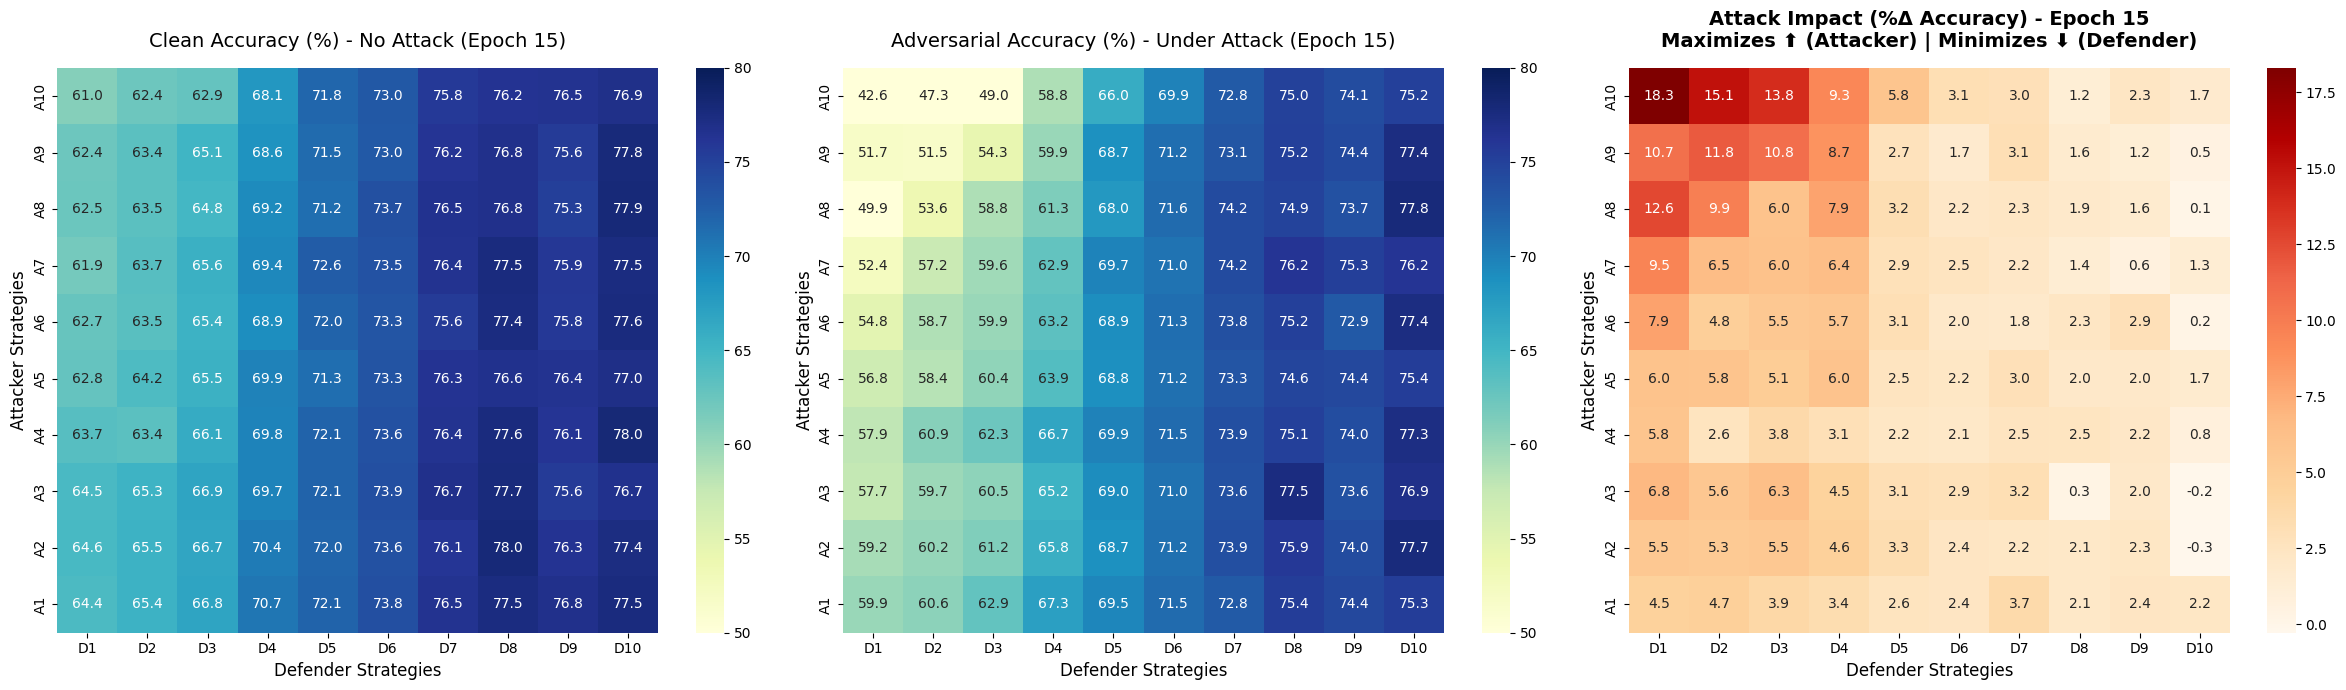



VISUALIZING EPOCH 16/20


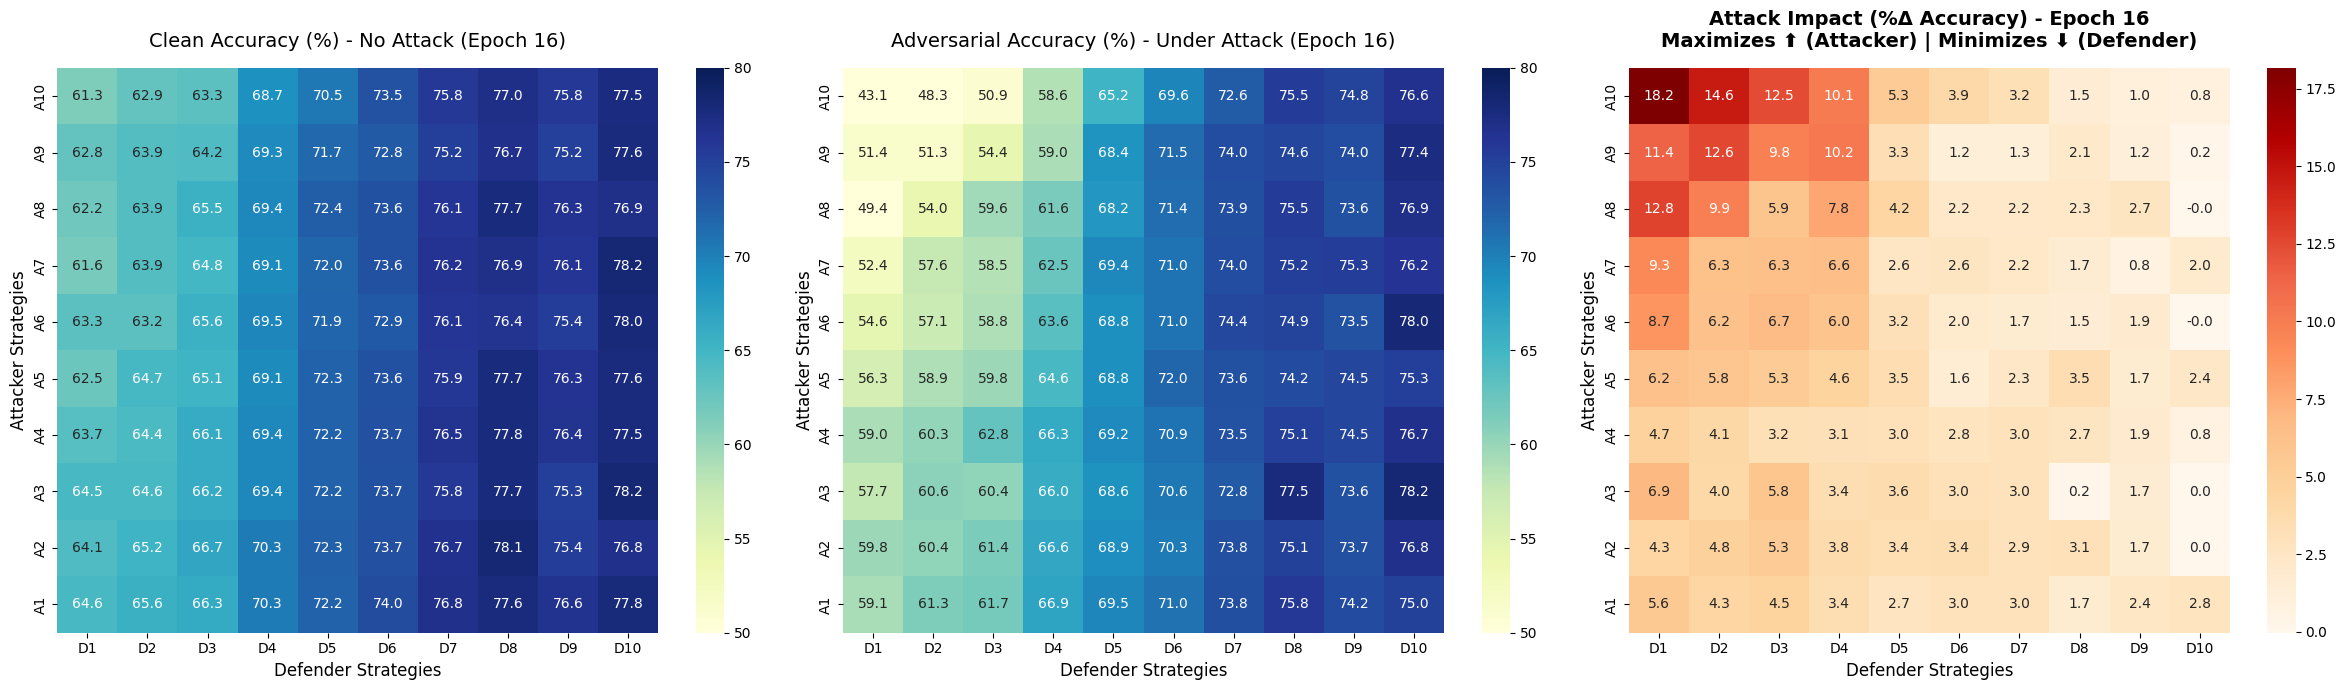



VISUALIZING EPOCH 17/20


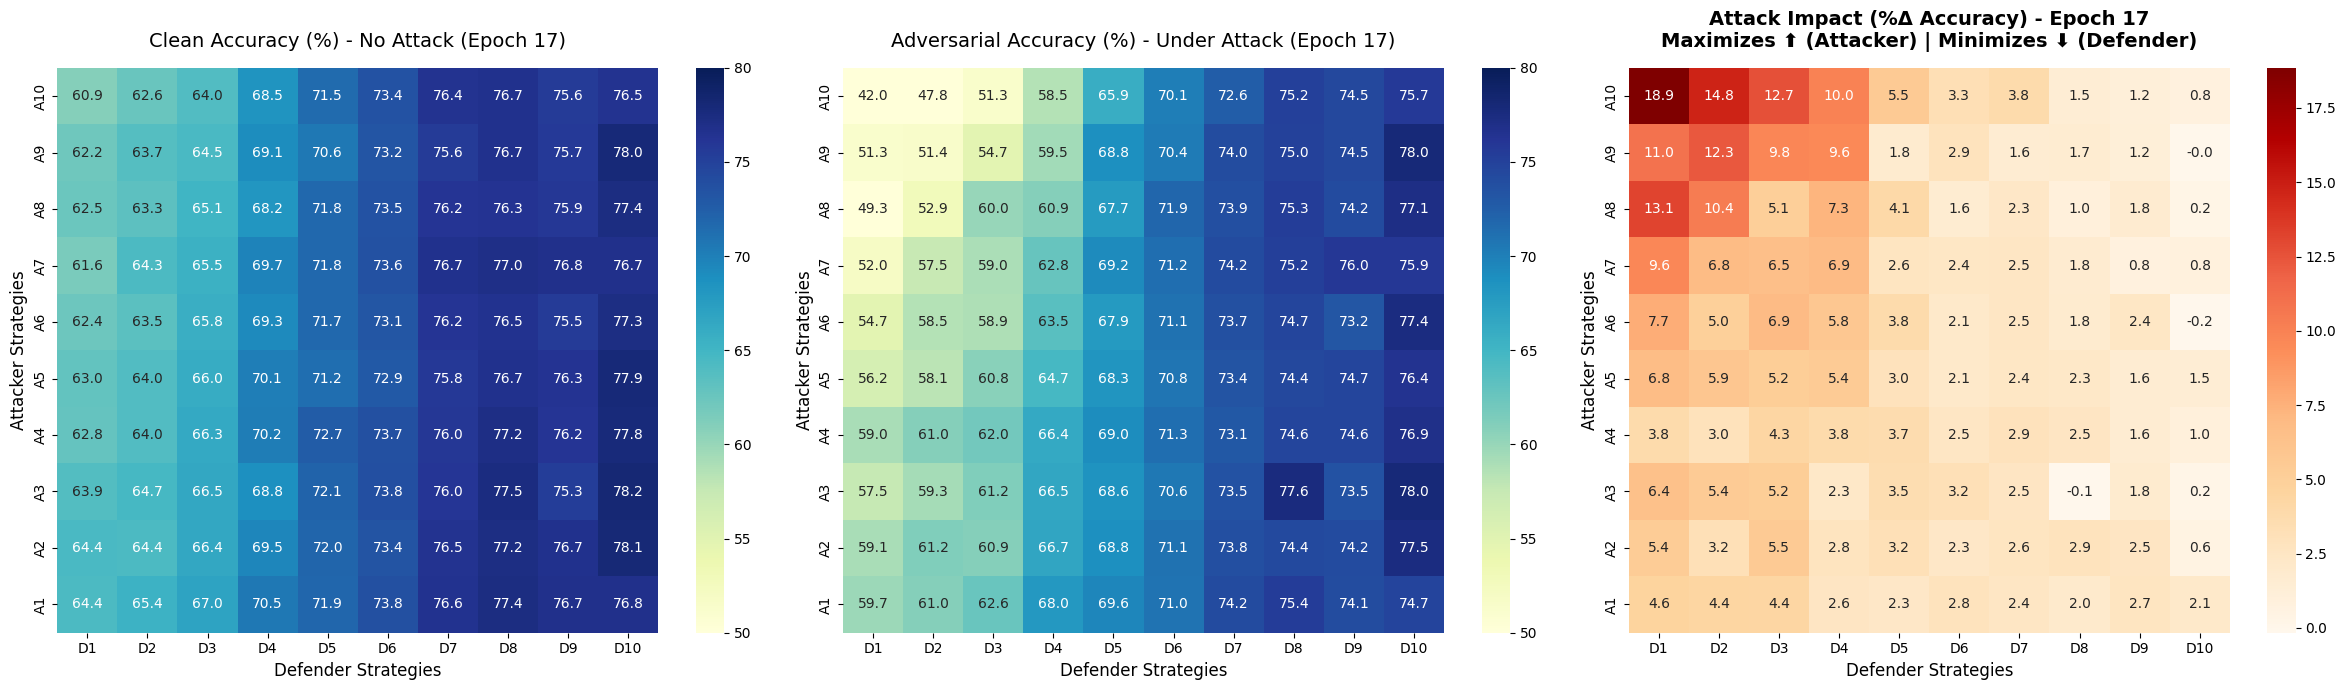



VISUALIZING EPOCH 18/20


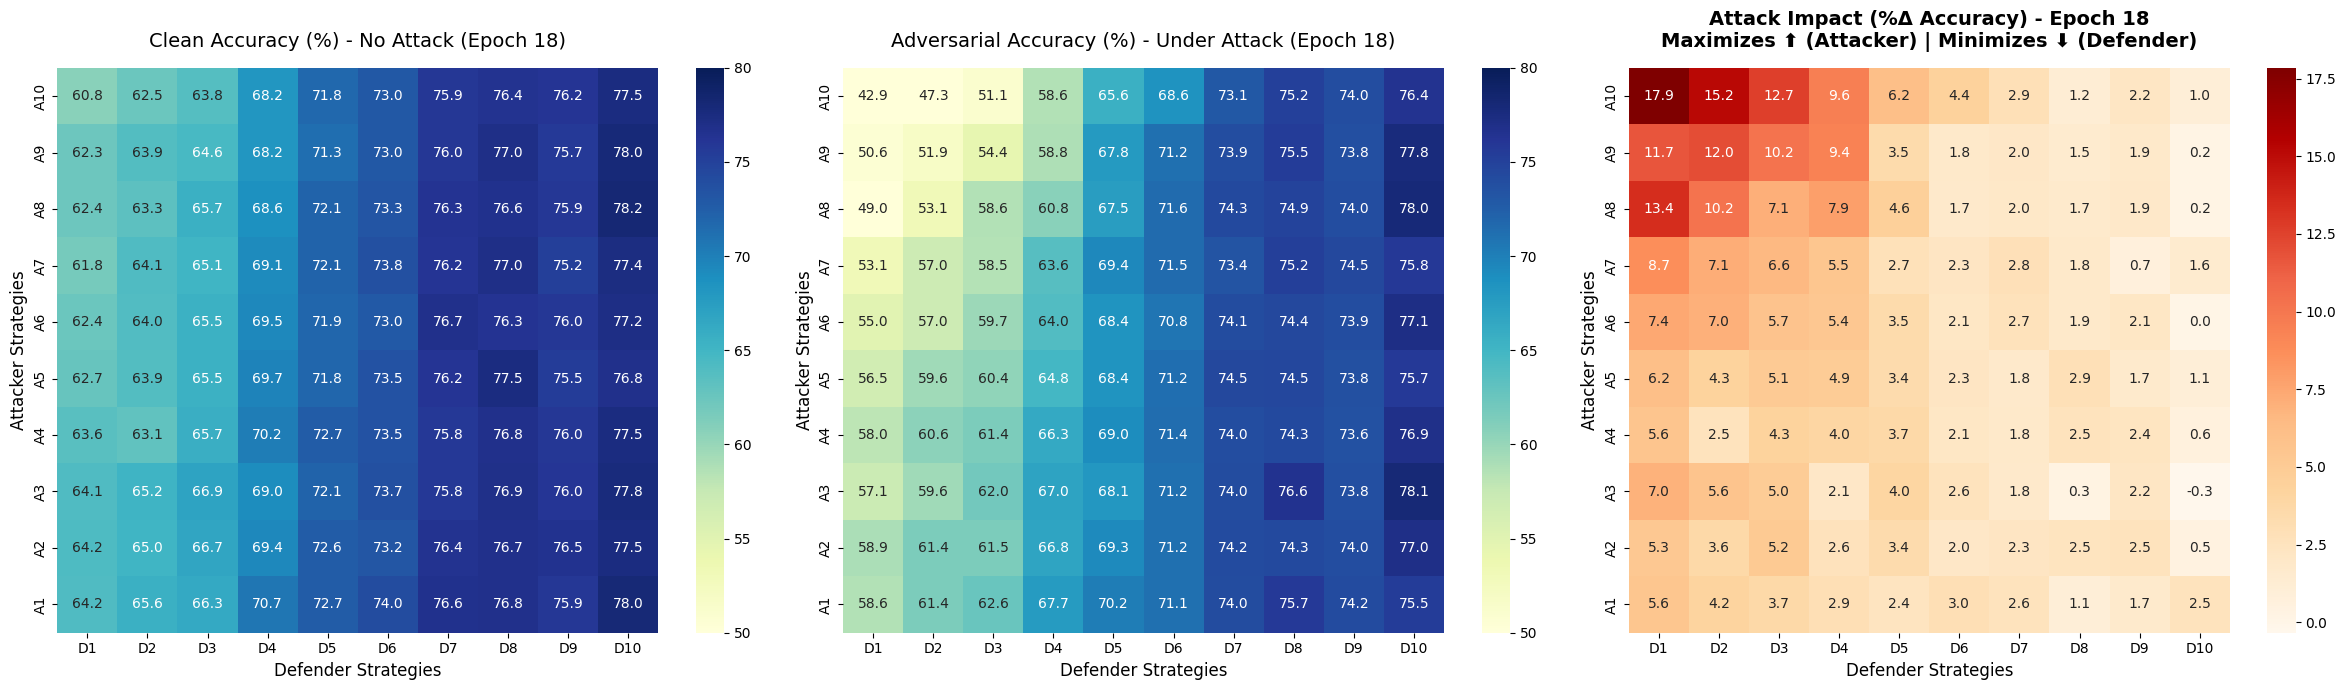



VISUALIZING EPOCH 19/20


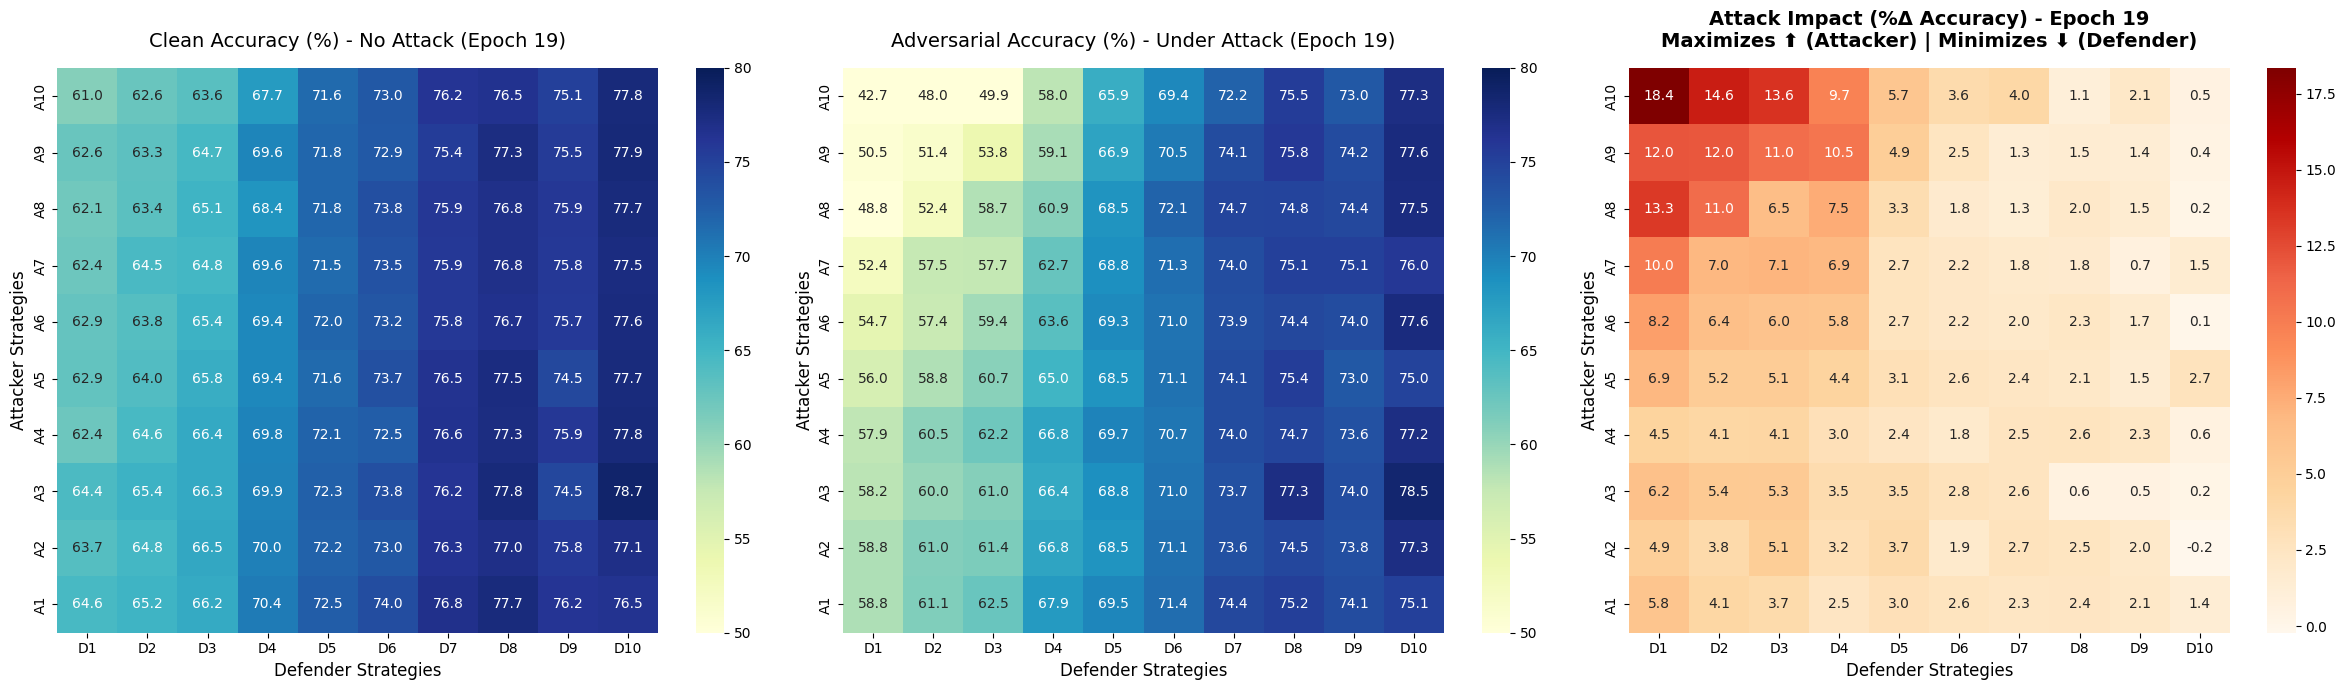



VISUALIZING EPOCH 20/20


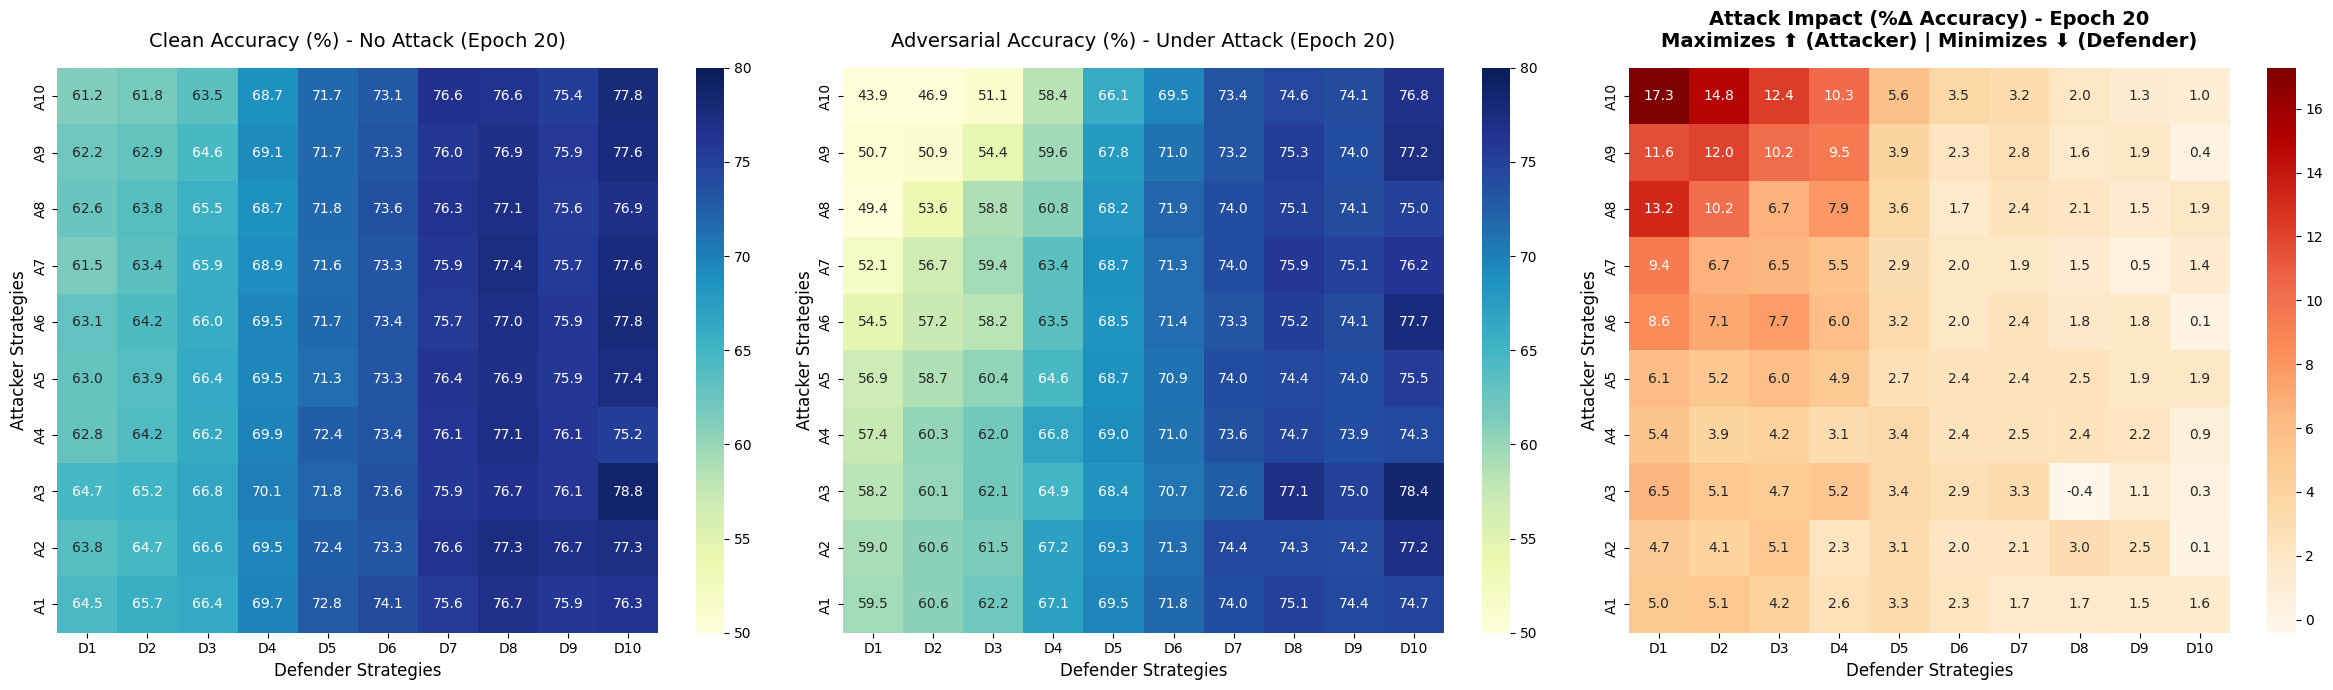

In [2]:
# Total number of epochs (first dimension of the matrix)
num_epochs = matriu_clean.shape[0]
print(f"Detected {num_epochs} epochs. Generating visualizations...\n")

attackers_labels = [f"A{i}" for i in range(1, 11)]
defenders_labels = [f"D{i}" for i in range(1, 11)]

means_clean = []
means_adv = []

for epoch in range(num_epochs):
    print(f"VISUALIZING EPOCH {epoch + 1}/{num_epochs}")
    
    current_clean = matriu_clean[epoch]
    current_adv = matriu_adv[epoch]
    current_delta = current_clean - current_adv
    
    # Save the means of this epoch for the final graph
    means_clean.append(np.mean(current_clean))
    means_adv.append(np.mean(current_adv))
    
    # Create the figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))


    # 1. Clean (Left)
    sns.heatmap(current_clean, annot=True, fmt=".1f", cmap="YlGnBu", 
                xticklabels=defenders_labels, yticklabels=attackers_labels, 
                ax=axes[0], vmin=50, vmax=80)
    axes[0].invert_yaxis()
    axes[0].set_title(f'Clean Accuracy (%) - No Attack (Epoch {epoch + 1})', fontsize=14, pad=15)
    axes[0].set_xlabel('Defender Strategies', fontsize=12)
    axes[0].set_ylabel('Attacker Strategies', fontsize=12)

    
    # 2. Adversarial (Middle)
    sns.heatmap(current_adv, annot=True, fmt=".1f", cmap="YlGnBu", 
                xticklabels=defenders_labels, yticklabels=attackers_labels, 
                ax=axes[1], vmin=50, vmax=80)
    axes[1].invert_yaxis() 
    axes[1].set_title(f'Adversarial Accuracy (%) - Under Attack (Epoch {epoch + 1})', fontsize=14, pad=15)
    axes[1].set_xlabel('Defender Strategies', fontsize=12)
    axes[1].set_ylabel('Attacker Strategies', fontsize=12)


    # 3. Delta Matrix / Impact (Right)
    sns.heatmap(current_delta, annot=True, fmt=".1f", cmap="OrRd",  
                xticklabels=defenders_labels, yticklabels=attackers_labels, 
                ax=axes[2])
    axes[2].invert_yaxis()
    axes[2].set_title(f"Attack Impact (%\u0394 Accuracy) - Epoch {epoch + 1}\nMaximizes ⬆ (Attacker) | Minimizes ⬇ (Defender)", 
                      fontsize=14, pad=15, fontweight='bold')
    axes[2].set_xlabel("Defender Strategies", fontsize=12)
    axes[2].set_ylabel("Attacker Strategies", fontsize=12)

    plt.tight_layout()
    plt.savefig(f'../../output/figures/accuracy_matrices/{size}x{size}_eps_{eps}/matrices_epoch_{epoch + 1}_{size}x{size}_eps_{eps}.png', dpi=300)
    plt.show()
    print("\n")

GLOBAL SUMMARY OF THE GAME


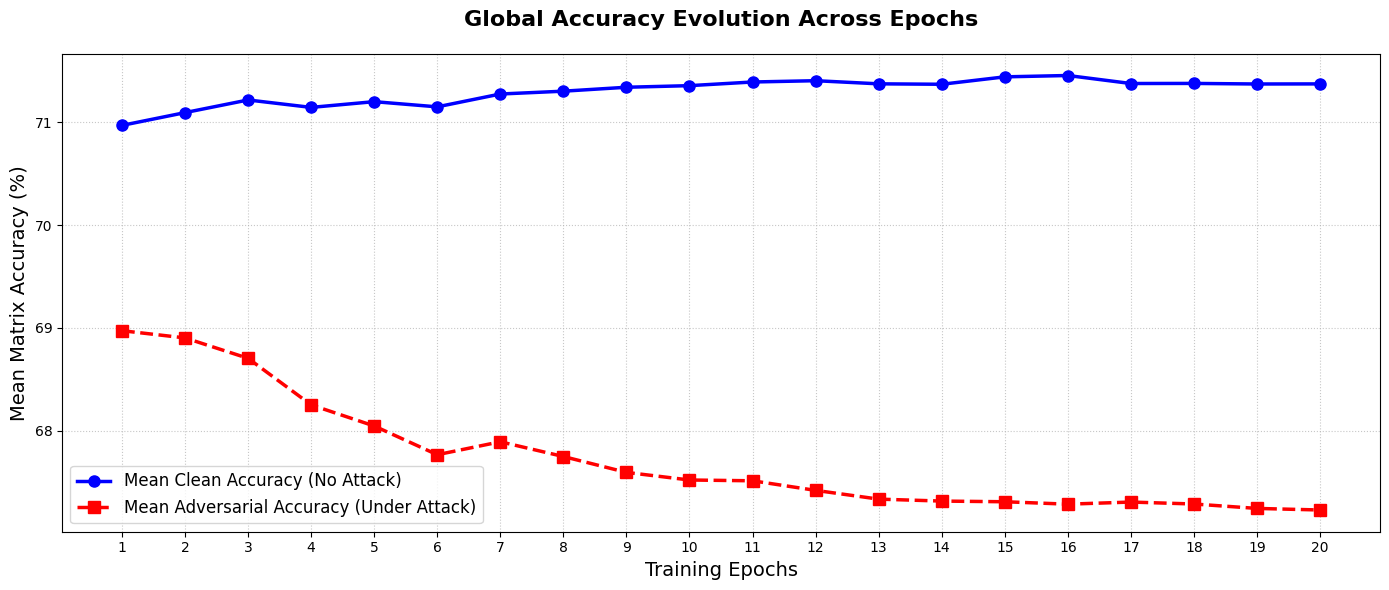

In [3]:
# GLOBAL EVOLUTION OF ALL EPOCHS
print(f"GLOBAL SUMMARY OF THE GAME")

plt.figure(figsize=(14, 6))

# Drawing the mean accuracy lines for both clean and adversarial conditions across epochs
plt.plot(range(1, num_epochs + 1), means_clean, label='Mean Clean Accuracy (No Attack)', 
         color='blue', marker='o', linewidth=2.5, markersize=8)
plt.plot(range(1, num_epochs + 1), means_adv, label='Mean Adversarial Accuracy (Under Attack)', 
         color='red', marker='s', linewidth=2.5, markersize=8, linestyle='--')

plt.title("Global Accuracy Evolution Across Epochs", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Training Epochs", fontsize=14)
plt.ylabel("Mean Matrix Accuracy (%)", fontsize=14)
plt.xticks(range(1, num_epochs + 1)) 
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()